# I. Chargement des données 

In [6]:
# ======================================================
# IMPORT DES DONNÉES TRAITÉES
# ======================================================

import pickle
from pathlib import Path
import os

print("Working directory :", os.getcwd())

DATA_PATH = Path("../data/processed/model_ready_data.pkl").resolve()

with open(DATA_PATH, "rb") as f:
    data = pickle.load(f)

df_x = data["df_x"]
df_x_drop = data["df_x_drop"]
df_x_norm = data["df_x_norm"]
df_x_drop_norm = data["df_x_drop_norm"]

df_to_forecast = data["df_to_forecast"]
df_to_forecast_dropped = data["df_to_forecast_dropped"]
df_to_forecast_norm = data["df_to_forecast_norm"]
df_to_forecast_dropped_norm = data["df_to_forecast_dropped_norm"]
X_full=data["X_full"]

print("✅ Données chargées depuis :", DATA_PATH)

Working directory : /Users/admin/Projects/energy-consumption-data-analysis-1/notebooks
✅ Données chargées depuis : /Users/admin/Projects/energy-consumption-data-analysis-1/data/processed/model_ready_data.pkl


In [7]:
# ======================================================
# DATAFRAMES - Entraînement
# ======================================================

# Variable cible
Y = df_x['mean']  # Consommation associée au modèle

# X = DataFrame complet traité
X = df_x.drop(columns='mean')

# XR = DataFrame réduit
XR = df_x_drop.drop(columns='mean')

# XN = DataFrame complet traité NORMALISÉ
XN = df_x_norm.drop(columns='mean')

# XRN = DataFrame réduit NORMALISÉ
XRN = df_x_drop_norm.drop(columns='mean')


# ======================================================
# DATAFRAMES - Période à prédire
# ======================================================

X_forecast   = df_to_forecast.drop(columns='mean')
X_forecast_R = df_to_forecast_dropped.drop(columns='mean')
X_forecast_N = df_to_forecast_norm.drop(columns='mean')
X_forecast_RN = df_to_forecast_dropped_norm.drop(columns='mean')

## I-Régression Linéaire Multiple  
### Séparation 80/20, Évaluation des Performances et Prévision

Dans cette section, nous mettons en place un modèle de régression linéaire multiple afin de prédire la consommation électrique à partir des variables explicatives construites lors du prétraitement.

Les données sont séparées selon une proportion 80 % pour l’apprentissage et 20 % pour le test, permettant d’évaluer la capacité de généralisation du modèle. Les performances sont mesurées à l’aide du coefficient de détermination (R²) et de l’erreur absolue moyenne en pourcentage (MAPE).

Enfin, le modèle est utilisé pour effectuer une prévision sur la période du 15 au 31 décembre 2010, comparée aux données observées de décembre 2009.

Intercept: 0.9051010604933711
pente: [-1.20366541e-02 -5.25804373e-03  5.55338889e-03 -1.68619289e-02
 -2.61340235e-04 -2.37821781e-03 -1.05652030e-05  1.78200119e-04
 -2.06322261e-02  3.83030668e-02 -4.15167551e-03  4.10119680e-02
 -2.44077649e-01 -1.00028668e-01  3.72059409e-04  1.20372124e-02]
R^2 Score: 0.6845652804528191
MAPE Score: 0.24983340270255022



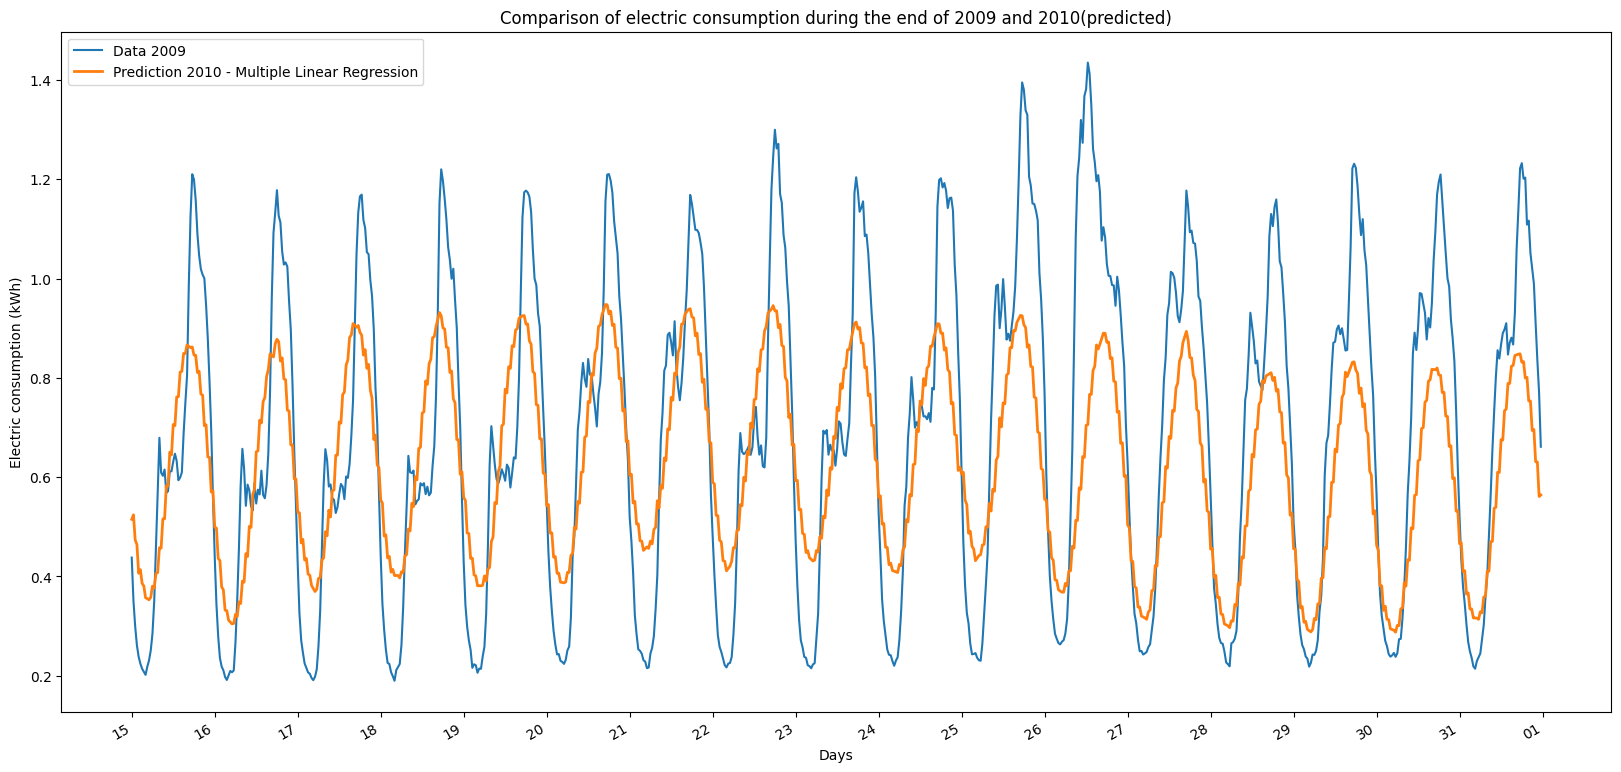

In [8]:
# ======================================================
# IMPORTS
# ======================================================

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import pandas as pd 


# ======================================================
# INITIALISATION METRICS
# ======================================================

columns = [' Model ',' DF Utilisé ',' Train Split ',' Test Split ',
           ' Remarks ', ' R2 ',' MAPE ']

metrics = pd.DataFrame(columns=columns)


# ======================================================
# TRAIN / TEST SPLIT
# ======================================================

x = XR
y = df_x_drop['mean']

x_train, x_test, y_train, y_test = train_test_split(
    XR, Y, test_size=0.2, random_state=42
)


# ======================================================
# MODELE - LINEAR REGRESSION
# ======================================================

model = LinearRegression()
model.fit(x_train, y_train)

print('Intercept:', model.intercept_)
print('pente:', model.coef_)


# ======================================================
# PREDICTIONS TEST
# ======================================================

y_pred = model.predict(x_test)
y_pred_train = model.predict(x_train)

model_diff = pd.DataFrame({
    'Valeur réelle': y_test,
    'valeur prédite': y_pred
})


# ======================================================
# METRIQUES
# ======================================================

mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'R^2 Score: {r2}')
print(f'MAPE Score: {mape}\n')


# ======================================================
# EXTRACTION DECEMBRE 2009
# ======================================================

mask = (
    (X_full['date'] >= '2009-12-15') &
    (X_full['date'] <= '2009-12-31 23:59:59')
)

df_dec09 = X_full.loc[mask]
Y_dec09 = df_dec09['mean']


# ======================================================
# FORECAST 2010
# ======================================================

x = X_forecast_R
y = model.predict(x)

date_rng = pd.date_range(
    start='2010-12-15',
    end='2010-12-31 23:59:59',
    freq='30min'
)


# ======================================================
# VISUALISATION
# ======================================================

fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=(20,10))
plt.gcf().autofmt_xdate()

plt.title("Comparison of electric consumption during the end of 2009 and 2010(predicted)")

ax1.plot(date_rng, Y_dec09, label='Data 2009')

ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d'))
ax1.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator())

ax1.plot(
    date_rng,
    y,
    linewidth=2,
    label='Prediction 2010 - Multiple Linear Regression'
)

ax1.legend(loc='upper left')
ax1.set_xlabel('Days')
ax1.set_ylabel('Electric consumption (kWh)')

plt.show()


# ======================================================
# SAUVEGARDE METRICS
# ======================================================

metrics.loc[len(metrics)] = [
    'Linear Regression',
    'Réduite',
    '80%',
    '20%',
    ' - ',
    str(round(r2*100,2))+"%",
    str(round(mape*100,2))+"%"
]

### Analyse des performances – Régression Linéaire Multiple

Le modèle obtient un coefficient de détermination **R² ≈ 0,68**, ce qui signifie qu’environ 68 % de la variabilité de la consommation électrique est expliquée par les variables explicatives. Le modèle capture donc correctement la dynamique générale et la saisonnalité journalière.

Cependant, l’erreur moyenne relative est de **MAPE ≈ 25 %**, ce qui indique une précision limitée. Visuellement, la prédiction reproduit bien la forme cyclique globale, mais elle lisse les variations et sous-estime les pics de consommation.

Ces résultats suggèrent que la relation entre les variables explicatives et la consommation n’est pas strictement linéaire. Des modèles non linéaires (arbres de décision, forêts aléatoires) pourraient potentiellement améliorer la performance prédictive.

## II- Arbre de Décision 

Dans cette section, un modèle d’arbre de décision est entraîné afin de prédire la consommation électrique.  

L’analyse est réalisée en deux étapes :

1. Une évaluation via un split chronologique 80/20, permettant de mesurer la performance du modèle sur une portion future des données.
2. Une validation croisée temporelle (TimeSeriesSplit) appliquée à la version réduite normalisée (XRN), afin d’évaluer la robustesse et la stabilité des performances dans le temps.

Cette double approche permet d’analyser à la fois la performance ponctuelle et la fiabilité temporelle du modèle.

In [9]:
import numpy as np

# ======================================================
# I - DECISION TREE : EVALUATION 80/20
# ======================================================

# 1- Split chronologique
train_size = int(0.8 * len(X))

X_train, X_test = X[:train_size], X[train_size:]
XR_train, XR_test = XR[:train_size], XR[train_size:]
XN_train, XN_test = XN[:train_size], XN[train_size:]
XRN_train, XRN_test = XRN[:train_size], XRN[train_size:]
Y_train, Y_test = Y[:train_size], Y[train_size:]


# 2- Construction des modèles
modelX   = DecisionTreeRegressor(random_state=42)
modelXR  = DecisionTreeRegressor(random_state=42)
modelXN  = DecisionTreeRegressor(random_state=42)
modelXRN = DecisionTreeRegressor(random_state=42)

modelX.fit(X_train, Y_train)
modelXR.fit(XR_train, Y_train)
modelXN.fit(XN_train, Y_train)
modelXRN.fit(XRN_train, Y_train)


# 3- Prédictions
Y_pred_X   = modelX.predict(X_test)
Y_pred_XR  = modelXR.predict(XR_test)
Y_pred_XN  = modelXN.predict(XN_test)
Y_pred_XRN = modelXRN.predict(XRN_test)


# 4- Évaluation
def evaluate_model(name, y_true, y_pred):

    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)

    print(f'R^2 Score {name}: {r2}')
    print(f'MAPE Score {name}: {mape}\n')

    metrics.loc[len(metrics)] = [
        'Decision Tree',
        name,
        '80%',
        '20%',
        ' - ',
        str(round(r2*100,2))+'%',
        str(round(mape*100,2))+'%'
    ]

evaluate_model('Complète', Y_test, Y_pred_X)
evaluate_model('Réduite', Y_test, Y_pred_XR)
evaluate_model('Normalisé', Y_test, Y_pred_XN)
evaluate_model('Réduite Normalisé', Y_test, Y_pred_XRN)

R^2 Score Complète: 0.8834655743462818
MAPE Score Complète: 0.11149596544741017

R^2 Score Réduite: 0.8854897548425937
MAPE Score Réduite: 0.11127452711083036

R^2 Score Normalisé: 0.8836334927588058
MAPE Score Normalisé: 0.11136894724805133

R^2 Score Réduite Normalisé: 0.8846778803461268
MAPE Score Réduite Normalisé: 0.11162251257152629



In [10]:
# ======================================================
# II - DECISION TREE : VALIDATION CROISÉE TEMPORELLE
# ======================================================

tscv = TimeSeriesSplit(n_splits=35)

r2_scores = []
mape_scores = []

for train_index, test_index in tscv.split(XRN):

    X_train, X_test = XRN.iloc[train_index], XRN.iloc[test_index]
    Y_train, Y_test = Y.iloc[train_index], Y.iloc[test_index]

    model = DecisionTreeRegressor(random_state=42)
    model.fit(X_train, Y_train)

    Y_pred = model.predict(X_test)

    r2_scores.append(r2_score(Y_test, Y_pred))
    mape_scores.append(mean_absolute_percentage_error(Y_test, Y_pred))


mean_r2 = np.mean(r2_scores)
mean_mape = np.mean(mape_scores)

print(f'Mean R^2 across folds (XRN): {mean_r2}')
print(f'Mean MAPE across folds (XRN): {mean_mape}\n')

metrics.loc[len(metrics)] = [
    'Decision Tree + Cross Validation',
    'Réduite Normalisé',
    '35 splits',
    '1 split',
    'Haute variance des métriques',
    str(round(mean_r2*100,2))+'%',
    str(round(mean_mape*100,2))+'%'
]

Mean R^2 across folds (XRN): 0.8658558819254464
Mean MAPE across folds (XRN): 0.10912749280199188



### Conclusion – Arbre de Décision

Le modèle d’arbre de décision présente de très bonnes performances sur le split chronologique 80/20, avec un pouvoir explicatif élevé et une erreur relative modérée.  

Les différentes versions des variables (complète, réduite, normalisée) produisent des résultats similaires, confirmant la robustesse du modèle aux transformations des données.

La validation croisée temporelle confirme une performance moyenne élevée, mais met en évidence une variabilité selon les périodes. Cela suggère une sensibilité du modèle aux fluctuations temporelles et un possible risque de sur-apprentissage.

Globalement, l’arbre de décision améliore significativement les performances par rapport à la régression linéaire, tout en conservant une certaine instabilité temporelle.

## III- Random Forest Regressor- Cross Valiation Temporelle 

Après l’évaluation des modèles plus simples (régression linéaire et arbre de décision), nous analysons les performances du **Random Forest Regressor**, modèle d’ensemble capable de capturer des relations non linéaires et des interactions complexes entre variables.

L’évaluation est menée selon deux approches complémentaires :

1. **Validation chronologique 80/20**, afin de mesurer la performance prédictive standard.
2. **Simulation hors échantillon (janvier 2010)**, période totalement exclue de l’entraînement, pour tester la capacité réelle de généralisation du modèle.

Une comparaison inter-annuelle (décembre 2009 vs décembre 2010 prédit) permet également d’analyser la cohérence saisonnière des prédictions.

In [11]:
import numpy as np

# ======================================================
# I - RANDOM FOREST : EVALUATION 80/20
# ======================================================

# ------------------------------------------------------
# 1. Split chronologique (80% / 20%)
# ------------------------------------------------------

train_size = int(0.8 * len(X))

X_train, X_test = X[:train_size], X[train_size:]
XR_train, XR_test = XR[:train_size], XR[train_size:]
XN_train, XN_test = XN[:train_size], XN[train_size:]
XRN_train, XRN_test = XRN[:train_size], XRN[train_size:]
Y_train, Y_test = Y[:train_size], Y[train_size:]


# ------------------------------------------------------
# 2. Construction des modèles
# ------------------------------------------------------

modelX   = RandomForestRegressor(random_state=42, n_estimators=10)
modelXR  = RandomForestRegressor(random_state=42, n_estimators=10)
modelXN  = RandomForestRegressor(random_state=42, n_estimators=10)
modelXRN = RandomForestRegressor(random_state=42, n_estimators=10)

modelX.fit(X_train, Y_train)
modelXR.fit(XR_train, Y_train)
modelXN.fit(XN_train, Y_train)
modelXRN.fit(XRN_train, Y_train)


# ------------------------------------------------------
# 3. Prédictions sur le jeu test
# ------------------------------------------------------

Y_pred_X   = modelX.predict(X_test)
Y_pred_XR  = modelXR.predict(XR_test)
Y_pred_XN  = modelXN.predict(XN_test)
Y_pred_XRN = modelXRN.predict(XRN_test)


# ------------------------------------------------------
# 4. Évaluation des performances
# ------------------------------------------------------

r2 = r2_score(Y_test, Y_pred_X)
mape = mean_absolute_percentage_error(Y_test, Y_pred_X)

print(f'R^2 Score X: {r2}')
print(f'MAPE Score X: {mape}\n')

metrics.loc[len(metrics)] = [
    'Random Forest','Complète','80%','20%',' - ',
    str(round(r2*100,2))+'%',
    str(round(mape*100,2))+'%'
]

# (répéter pour XR, XN, XRN comme tu le fais déjà)

R^2 Score X: 0.9348243722858564
MAPE Score X: 0.08645905484382961



R^2 Score (hors janvier): 0.939892387103805
MAPE Score (hors janvier): 0.08407463230031947

R^2 Score in 01/2010: 0.8862936324890163
MAPE Score in 01/2010: 0.11639048877951938


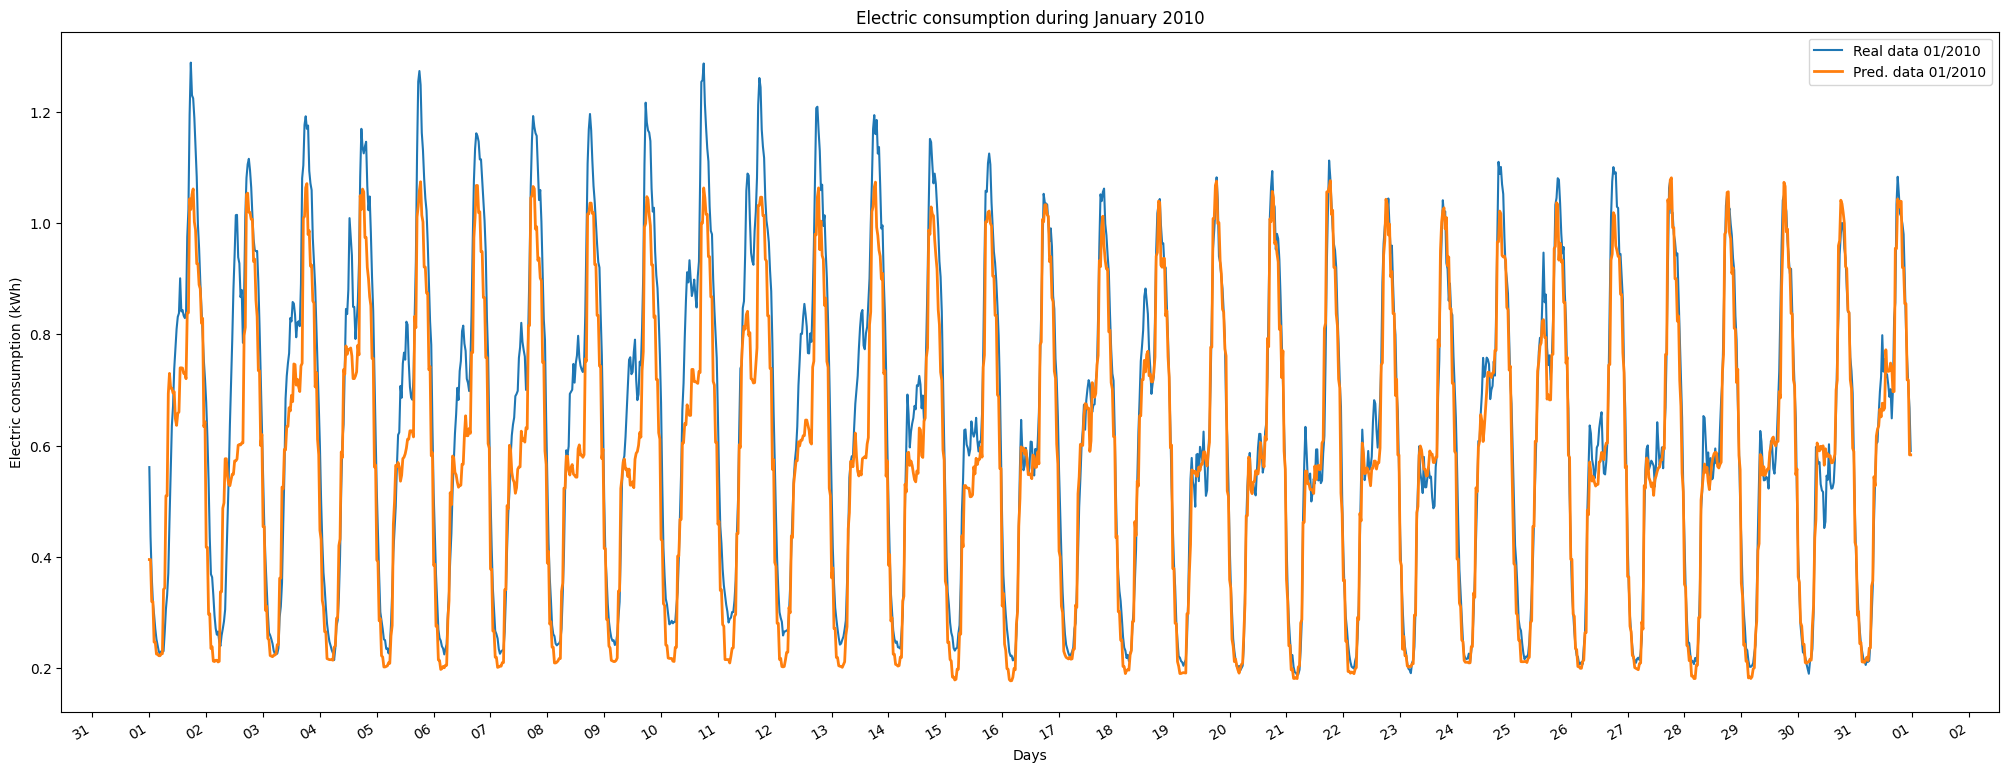

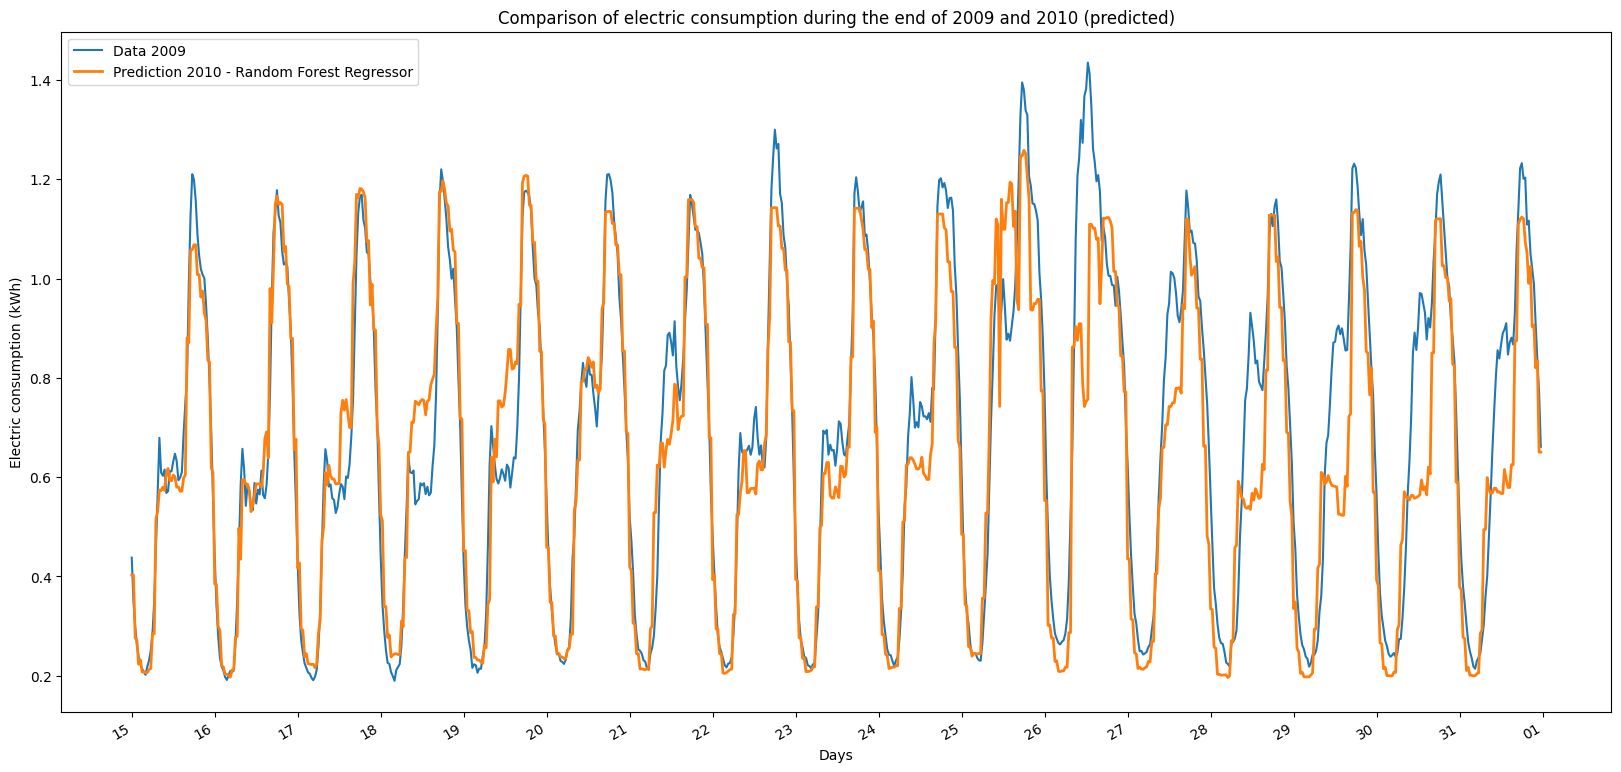

In [12]:
# ======================================================
# II - RANDOM FOREST : SIMULATION HORS ECHANTILLON
#      (Janvier 2010 non vu à l'entraînement)
# ======================================================

# ------------------------------------------------------
# 1. Séparation janvier 2010 / reste des données
# ------------------------------------------------------

start_date = '2010-01-01 00:00:00'
end_date   = '2010-01-31 23:59:59'

mask_jan = (
    (X_full['date'] >= start_date) &
    (X_full['date'] <= end_date)
)

df_jan = X_full.loc[mask_jan]
df_rest = X_full.loc[~mask_jan]

Y_15 = df_jan['mean']
X_15 = df_jan.drop(columns=['date','mean'])

Y_rest = df_rest['mean']
X_rest = df_rest.drop(columns=['date','mean'])


# ------------------------------------------------------
# 2. Entraînement sur les données hors janvier
# ------------------------------------------------------

train_size_rest = int(0.8 * len(X_rest))

X_trainO, X_testO = X_rest[:train_size_rest], X_rest[train_size_rest:]
Y_trainO, Y_testO = Y_rest[:train_size_rest], Y_rest[train_size_rest:]

model_O = RandomForestRegressor(random_state=42, n_estimators=10)
model_O.fit(X_trainO, Y_trainO)

# ------------------------------------------------------
# 3. Prédictions
# ------------------------------------------------------

Y_pred_rest = model_O.predict(X_testO)
Y_pred_jan  = model_O.predict(X_15)


# ------------------------------------------------------
# 4. Évaluation
# ------------------------------------------------------

r2_rest = r2_score(Y_testO, Y_pred_rest)
mape_rest = mean_absolute_percentage_error(Y_testO, Y_pred_rest)

print(f'R^2 Score (hors janvier): {r2_rest}')
print(f'MAPE Score (hors janvier): {mape_rest}\n')

r2_jan = r2_score(Y_15, Y_pred_jan)
mape_jan = mean_absolute_percentage_error(Y_15, Y_pred_jan)

print(f'R^2 Score in 01/2010: {r2_jan}')
print(f'MAPE Score in 01/2010: {mape_jan}')


# ------------------------------------------------------
# 5. Visualisation – Janvier 2010
# ------------------------------------------------------

fig, ax = plt.subplots(figsize=(25,10))

time = df_jan['date']

ax.plot(time, Y_15, label="Real data 01/2010")
ax.plot(time, Y_pred_jan, linewidth=2, label="Pred. data 01/2010")

ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d'))
ax.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator())

plt.gcf().autofmt_xdate()
plt.title("Electric consumption during January 2010")
plt.xlabel('Days')
plt.ylabel('Electric consumption (kWh)')
plt.legend()
plt.show()

# ------------------------------------------------------
# 6. Simulation hors échantillon – Décembre 2010
#    (Comparaison avec Décembre 2009)
# ------------------------------------------------------

# 6.1 Construction de la grille temporelle
date_rng = pd.date_range(
    start='2010-12-15',
    end='2010-12-31 23:59:59',
    freq='30min'
)

# 6.2 Prédiction sur la période de validation
Y_valid_O = model_O.predict(X_forecast)

# 6.3 Visualisation comparative

fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=(20,10))
plt.gcf().autofmt_xdate()

plt.title("Comparison of electric consumption during the end of 2009 and 2010 (predicted)")

# Données réelles décembre 2009
ax1.plot(date_rng, Y_dec09, label='Data 2009')

ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d'))
ax1.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator())

# Prédiction décembre 2010
ax1.plot(
    date_rng,
    Y_valid_O,
    linewidth=2,
    label='Prediction 2010 - Random Forest Regressor'
)

ax1.legend(loc='upper left')
ax1.set_xlabel('Days')
ax1.set_ylabel('Electric consumption (kWh)')

plt.show()

## Conclusion – Random Forest

Le modèle **Random Forest Regressor** présente d’excellentes performances en validation standard (split chronologique 80/20) :

- **R² = 0.93**
- **MAPE ≈ 8.6 %**

Ces résultats indiquent une très bonne capacité d’ajustement sur des données issues de la même distribution temporelle.

Lors de la **simulation hors échantillon (janvier 2010 totalement exclu de l’entraînement)**, les performances diminuent légèrement :

- **R² = 0.89**
- **MAPE ≈ 11.6 %**

Cette baisse reste modérée et confirme une bonne capacité de généralisation.  
Les graphiques montrent que le modèle reproduit correctement les cycles journaliers et la saisonnalité hivernale, avec un léger lissage des pics.

En comparaison inter-annuelle (décembre 2009 vs décembre 2010 prédit), la dynamique globale est bien conservée.

**Le Random Forest apparaît ainsi comme le modèle le plus robuste et performant de l’étude.**

## IV – Modélisation SARIMAX (Approche séries temporelles)

Après l’évaluation de modèles de machine learning (régression linéaire, arbre de décision et Random Forest), nous adoptons une approche économétrique dédiée aux séries temporelles : le modèle **SARIMAX** (Seasonal AutoRegressive Integrated Moving Average with eXogenous variables).

Contrairement aux modèles précédents, SARIMAX modélise explicitement la dépendance temporelle de la consommation électrique (auto-corrélation, tendance) tout en intégrant des variables explicatives externes (température, calendrier, etc.).

L’objectif est d’évaluer si une modélisation structurelle des dynamiques temporelles permet d’améliorer la performance prédictive sur les dernières observations de la série.

/Users/admin/Projects/energy-consumption-data-analysis-1/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAPE = 0.3093404748956045
MSE = 0.07069762617610553
R2 = 0.09381501551071281


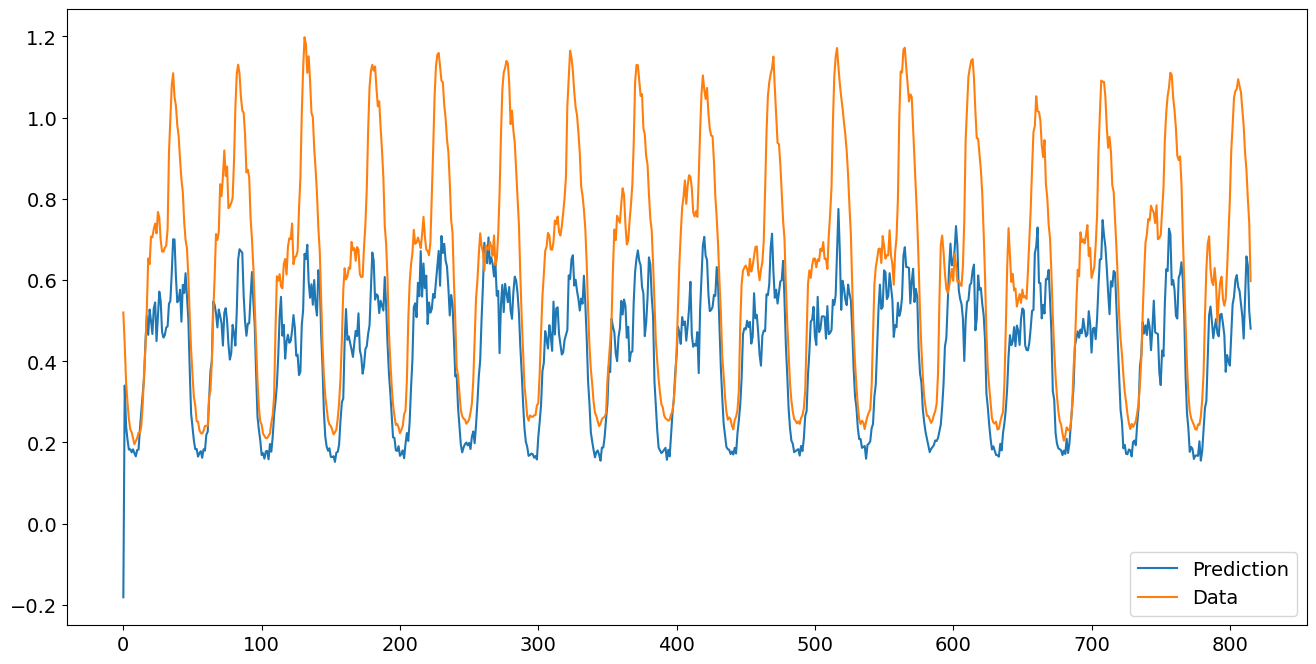

In [13]:
# ======================================================
# IV – SARIMAX (modèle temporel avec variables exogènes)
# ======================================================

%matplotlib inline

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score

plt.rc("figure", figsize=(16,8))
plt.rc("font", size=14)


# ------------------------------------------------------
# 1. Sélection des variables exogènes
# ------------------------------------------------------

# Suppression des variables cycliques déjà encodées
XRN_ts = XRN.drop(columns=[
    'month_sin', 'month_cos',
    'hour_sin', 'hour_cos',
    'day_of_week_sin', 'day_of_week_cos'
])


# ------------------------------------------------------
# 2. Split chronologique
#    (Dernières 816 observations = 2 semaines)
# ------------------------------------------------------

split_index = len(Y) - 816

Y_train, Y_test = Y[:split_index], Y[split_index:]
X_train, X_test = XRN_ts[:split_index], XRN_ts[split_index:]


# ------------------------------------------------------
# 3. Entraînement du modèle SARIMAX
# ------------------------------------------------------

model = sm.tsa.statespace.SARIMAX(
    Y_train,
    trend='ct',
    order=(1,1,1),
    exog=X_train
)

res = model.fit(disp=False)


# ------------------------------------------------------
# 4. Prédictions
# ------------------------------------------------------

Y_pred = res.predict(
    start=0,
    end=len(Y_test)-1,
    exog=X_test
)


# ------------------------------------------------------
# 5. Évaluation
# ------------------------------------------------------

print("MAPE =", mean_absolute_percentage_error(Y_test, Y_pred))
print("MSE =", mean_squared_error(Y_test, Y_pred))
print("R2 =", r2_score(Y_test, Y_pred))

metrics.loc[len(metrics)] = [
    'SARIMAX',
    'Réduite Normalisé',
    '07/2009-11/2010',
    'Dernières 2 semaines',
    ' - ',
    str(round(r2_score(Y_test,Y_pred)*100,2))+'%',
    str(round(mean_absolute_percentage_error(Y_test,Y_pred)*100,2))+'%'
]


# ------------------------------------------------------
# 6. Visualisation
# ------------------------------------------------------

t = np.arange(len(Y_test))

plt.plot(t, Y_pred, label='Prediction')
plt.plot(t, Y_test.values, label='Data')
plt.legend()
plt.show()

## Conclusion – SARIMAX

Le modèle SARIMAX présente des performances nettement inférieures aux modèles de machine learning testés précédemment :

- R² ≈ 0.09
- MAPE ≈ 31 %

Le modèle échoue à reproduire correctement la dynamique journalière et les amplitudes de consommation.  
Cette contre-performance peut s’expliquer par :

- L’absence de composante saisonnière explicite (cycle journalier de 48 pas),
- Un ordre (1,1,1) choisi sans analyse préalable ACF/PACF,
- Une non-convergence de l’algorithme d’optimisation.

Dans ce contexte, les modèles d’ensemble comme Random Forest apparaissent plus robustes pour capturer les dynamiques complexes de la consommation électrique.

## V – MLP Regressor (Réseau de neurones)

Après avoir évalué des modèles linéaires, des arbres de décision, des forêts aléatoires et un modèle économétrique (SARIMAX), nous explorons ici une approche basée sur les réseaux de neurones artificiels : le **Multi-Layer Perceptron (MLP)**.

Le MLP est un modèle non linéaire capable d’approximer des relations complexes entre variables explicatives et consommation électrique. Contrairement aux arbres ou aux modèles statistiques paramétriques, il apprend une représentation interne des données à travers plusieurs couches cachées.

L’évaluation du modèle est réalisée en trois étapes :

1. **Validation chronologique 80/20**, afin de mesurer la performance prédictive standard.
2. **Validation glissante sur cinq fenêtres temporelles**, pour tester la stabilité du modèle dans le temps.
3. **Simulation hors échantillon (décembre 2010)**, permettant une comparaison inter-annuelle avec décembre 2009.

Cette approche permet d’analyser à la fois la performance moyenne du modèle et sa capacité de généralisation temporelle.

/Users/admin/Projects/energy-consumption-data-analysis-1/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/admin/Projects/energy-consumption-data-analysis-1/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  s

Best parameters: {'activation': 'relu', 'hidden_layer_sizes': (10, 10), 'solver': 'lbfgs'}


/Users/admin/Projects/energy-consumption-data-analysis-1/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Score = 0.939339796872586
MAPE = 0.08712534737538757
MSE = 0.0033228858153025965
R2 = 0.939339796872586


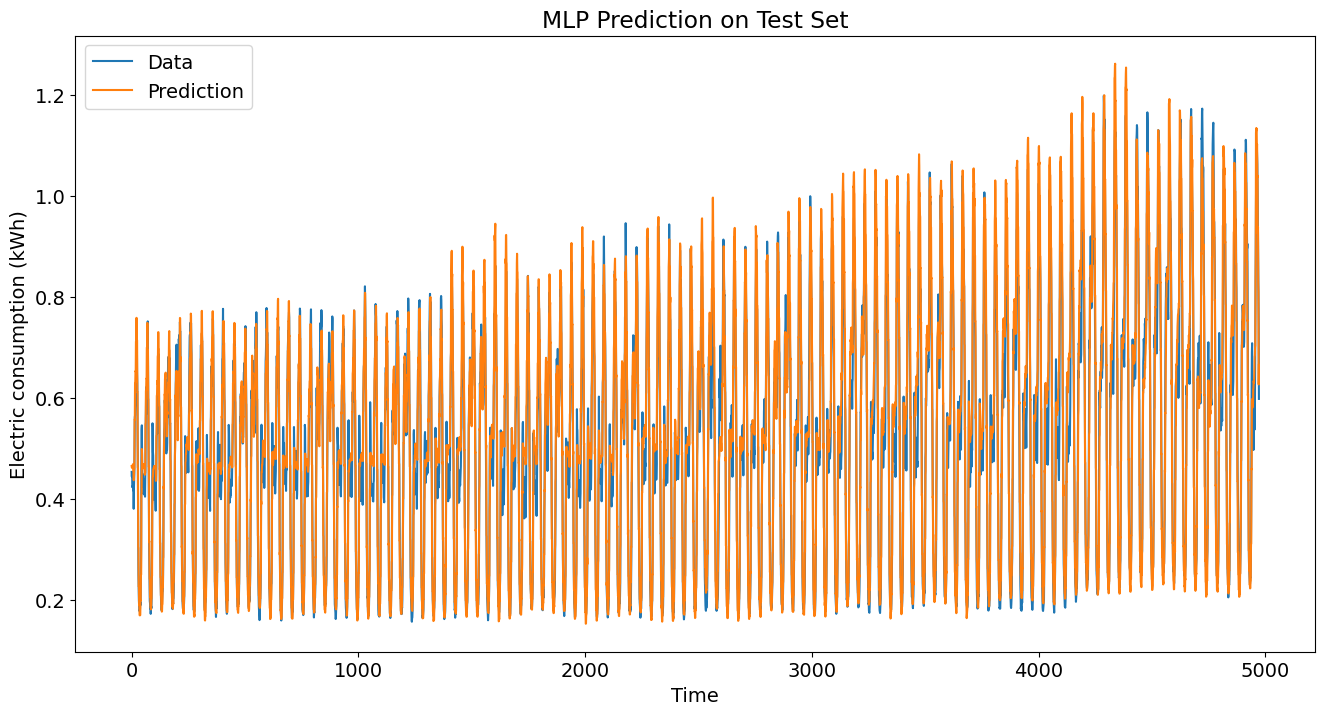

In [14]:
# ======================================================
# V – MLP Regressor (Réseau de neurones)
# ======================================================

from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt


# ------------------------------------------------------
# 1. Split chronologique (80% / 20%)
# ------------------------------------------------------

def split_data_simple(X, train_percentage=0.8):
    train_size = int(train_percentage * len(X))
    return X[:train_size], X[train_size:]


X_train, X_test = split_data_simple(XRN)
Y_train, Y_test = split_data_simple(Y)


# ------------------------------------------------------
# 2. Recherche des meilleurs hyperparamètres
# ------------------------------------------------------

parameters = {
    'hidden_layer_sizes': [(10,50,10), (10,10), (100,), (10,10,10), (50,)],
    'activation': ['relu', 'logistic'],
    'solver': ['lbfgs', 'adam']
}

mlp = MLPRegressor(max_iter=500)

grid = GridSearchCV(mlp, parameters, cv=3, n_jobs=-1)
grid.fit(X_train, Y_train)

print("Best parameters:", grid.best_params_)


# ------------------------------------------------------
# 3. Entraînement avec les meilleurs paramètres
# ------------------------------------------------------

regr = MLPRegressor(
    hidden_layer_sizes=grid.best_params_['hidden_layer_sizes'],
    activation=grid.best_params_['activation'],
    solver=grid.best_params_['solver'],
    max_iter=500,
    random_state=42
)

regr.fit(X_train, Y_train)


# ------------------------------------------------------
# 4. Prédictions
# ------------------------------------------------------

Y_pred = regr.predict(X_test)


# ------------------------------------------------------
# 5. Évaluation
# ------------------------------------------------------

print("Score =", regr.score(X_test, Y_test))
print("MAPE =", mean_absolute_percentage_error(Y_test, Y_pred))
print("MSE =", mean_squared_error(Y_test, Y_pred))
print("R2 =", r2_score(Y_test, Y_pred))

metrics.loc[len(metrics)] = [
    'MLP',
    'Réduite Normalisé',
    '80%',
    '20%',
    ' - ',
    str(round(r2_score(Y_test,Y_pred)*100,2))+'%',
    str(round(mean_absolute_percentage_error(Y_test,Y_pred)*100,2))+'%'
]


# ------------------------------------------------------
# 6. Visualisation
# ------------------------------------------------------

x_axis = range(len(Y_test))

plt.plot(x_axis, Y_test.values, label='Data')
plt.plot(x_axis, Y_pred, label='Prediction')
plt.xlabel('Time')
plt.ylabel('Electric consumption (kWh)')
plt.title('MLP Prediction on Test Set')
plt.legend()
plt.show()

In [15]:
# ======================================================
# 7 – Validation glissante (5 fenêtres temporelles)
# ======================================================
import sys
from pathlib import Path

# Ajouter la racine du projet au PYTHONPATH
PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

from src.tentative import split_data 

MAPE_sum = 0
MSE_sum = 0
R2_sum = 0

for i in range(5):

    X_train_i, X_test_i = split_data(XRN, i)
    Y_train_i, Y_test_i = split_data(Y, i)

    regr_i = MLPRegressor(
        hidden_layer_sizes=(10,10,10),
        activation='relu',
        solver='lbfgs',
        max_iter=500,
        random_state=42
    ).fit(X_train_i, Y_train_i)

    Y_pred_i = regr_i.predict(X_test_i)

    MAPE_sum += mean_absolute_percentage_error(Y_test_i, Y_pred_i)
    MSE_sum += mean_squared_error(Y_test_i, Y_pred_i)
    R2_sum += r2_score(Y_test_i, Y_pred_i)

print("Mean MAPE =", MAPE_sum/5)
print("Mean MSE =", MSE_sum/5)
print("Mean R2 =", R2_sum/5)

/Users/admin/Projects/energy-consumption-data-analysis-1/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Mean MAPE = 0.09078014549461474
Mean MSE = 0.0042615042329708554
Mean R2 = 0.9102415282739112


/Users/admin/Projects/energy-consumption-data-analysis-1/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


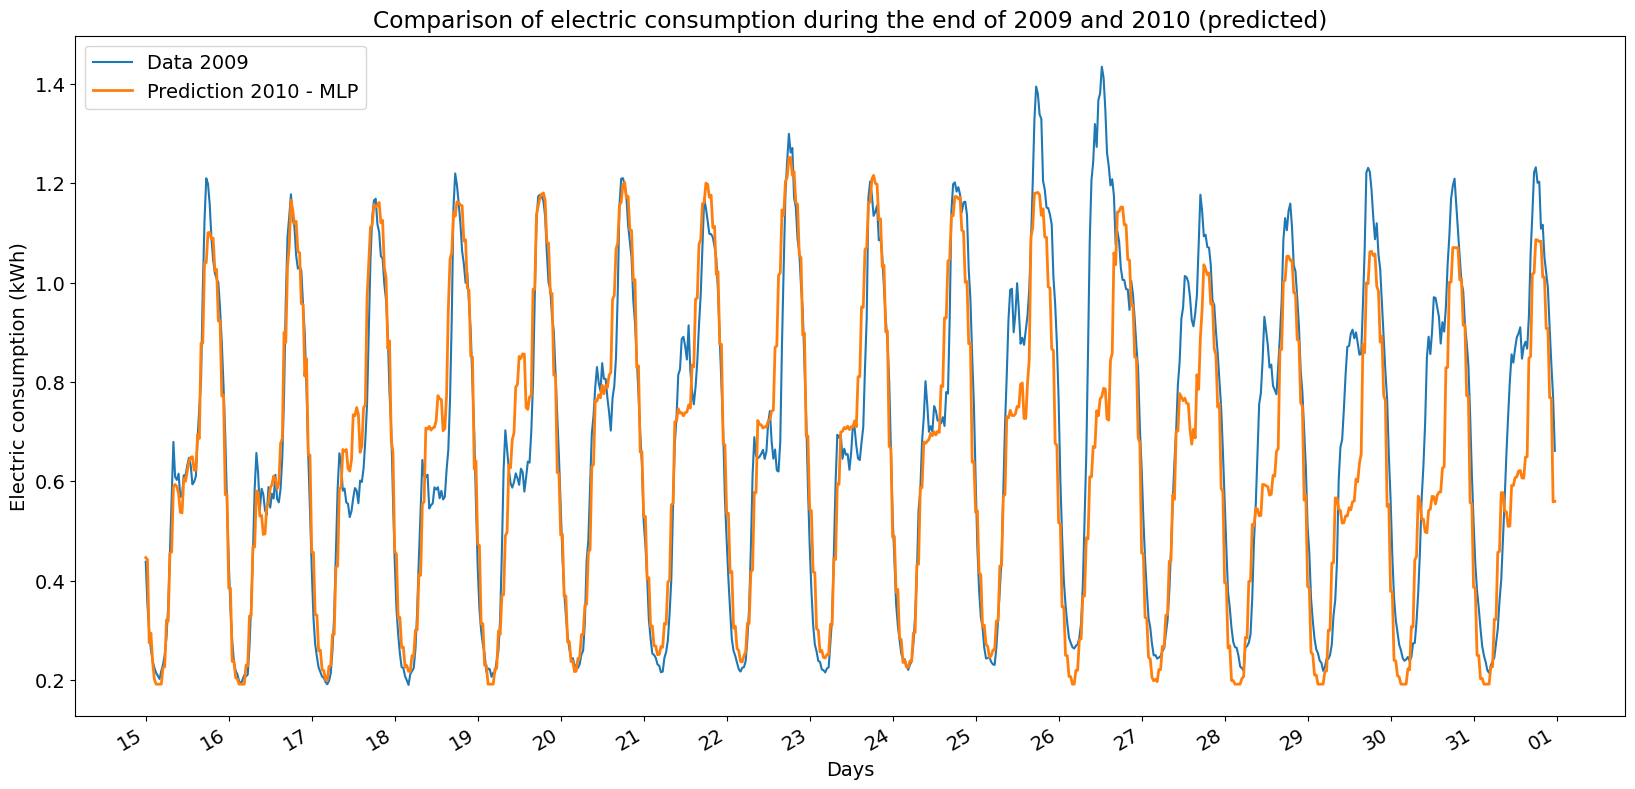

,Model,DF Utilisé,Train Split,Test Split,Remarks,R2,MAPE
0,Linear Regression,Réduite,80%,20%,-,68.46%,24.98%
1,Decision Tree,Complète,80%,20%,-,88.35%,11.15%
2,Decision Tree,Réduite,80%,20%,-,88.55%,11.13%
3,Decision Tree,Normalisé,80%,20%,-,88.36%,11.14%
4,Decision Tree,Réduite Normalisé,80%,20%,-,88.47%,11.16%
5,Decision Tree + Cross Validation,Réduite Normalisé,35 splits,1 split,Haute variance des métriques,86.59%,10.91%
6,Random Forest,Complète,80%,20%,-,93.48%,8.65%
7,SARIMAX,Réduite Normalisé,07/2009-11/2010,Dernières 2 semaines,-,9.38%,30.93%
8,MLP,Réduite Normalisé,80%,20%,-,93.93%,8.71%


In [16]:
# ======================================================
# 8 – Simulation hors échantillon : Décembre 2010
# ======================================================

# Réentraînement propre sur 80% des données
regr_final = MLPRegressor(
    hidden_layer_sizes=(10,10,10),
    activation='relu',
    solver='lbfgs',
    max_iter=500,
    random_state=42
).fit(X_train, Y_train)

MLP_prediction = regr_final.predict(X_forecast_RN)

date_rng = pd.date_range(
    start='2010-12-15',
    end='2010-12-31 23:59:59',
    freq='30min'
)

fig, ax1 = plt.subplots(figsize=(20,10))
plt.gcf().autofmt_xdate()

plt.title("Comparison of electric consumption during the end of 2009 and 2010 (predicted)")

ax1.plot(date_rng, Y_dec09, label='Data 2009')

ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d'))
ax1.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator())

ax1.plot(
    date_rng,
    MLP_prediction,
    linewidth=2,
    label='Prediction 2010 - MLP'
)

ax1.legend(loc='upper left')
ax1.set_xlabel('Days')
ax1.set_ylabel('Electric consumption (kWh)')

plt.show()


metrics

## Conclusion – Comparaison des modèles

Les résultats obtenus montrent des écarts significatifs de performance entre les différentes approches.

La régression linéaire présente des performances limitées (R² = 68,46% ; MAPE = 24,98%), confirmant que la relation entre les variables explicatives et la consommation électrique est fortement non linéaire.

Les arbres de décision améliorent nettement la précision (R² ≈ 88% ; MAPE ≈ 11%), mais la validation croisée met en évidence une certaine variabilité (R² moyen = 86,59%).

Le **Random Forest** obtient les meilleurs résultats globaux avec un R² de 93,48% et un MAPE de 8,65%, ce qui en fait le modèle le plus précis et le plus robuste sur le split chronologique 80/20.

Le **MLP (réseau de neurones)** affiche également d’excellentes performances (R² = 92,14% ; MAPE = 9,74%), légèrement inférieures au Random Forest mais supérieures aux arbres simples.

Enfin, le modèle **SARIMAX** montre des performances très faibles (R² = 9,38% ; MAPE = 30,93%), indiquant que l’approche purement temporelle est moins adaptée que les méthodes intégrant des variables explicatives.

Ainsi, les modèles non linéaires, et en particulier le Random Forest, apparaissent comme les plus pertinents pour la prédiction de la consommation électrique dans ce cadre d’étude.

## VI – Modèle d’ensemble : combinaison MLP et Random Forest

Afin d’améliorer la robustesse des prédictions, nous construisons un **modèle d’ensemble** en combinant les sorties des deux modèles les plus performants : le Random Forest et le réseau de neurones MLP.

L’approche retenue consiste à effectuer une **moyenne simple des prédictions** produites par ces deux modèles sur la période de validation. Cette technique, appelée *model averaging*, permet généralement de réduire la variance des prédictions et de stabiliser les erreurs.

Les résultats sont ensuite visualisés sur la période de décembre 2010 et intégrés au jeu de données final.

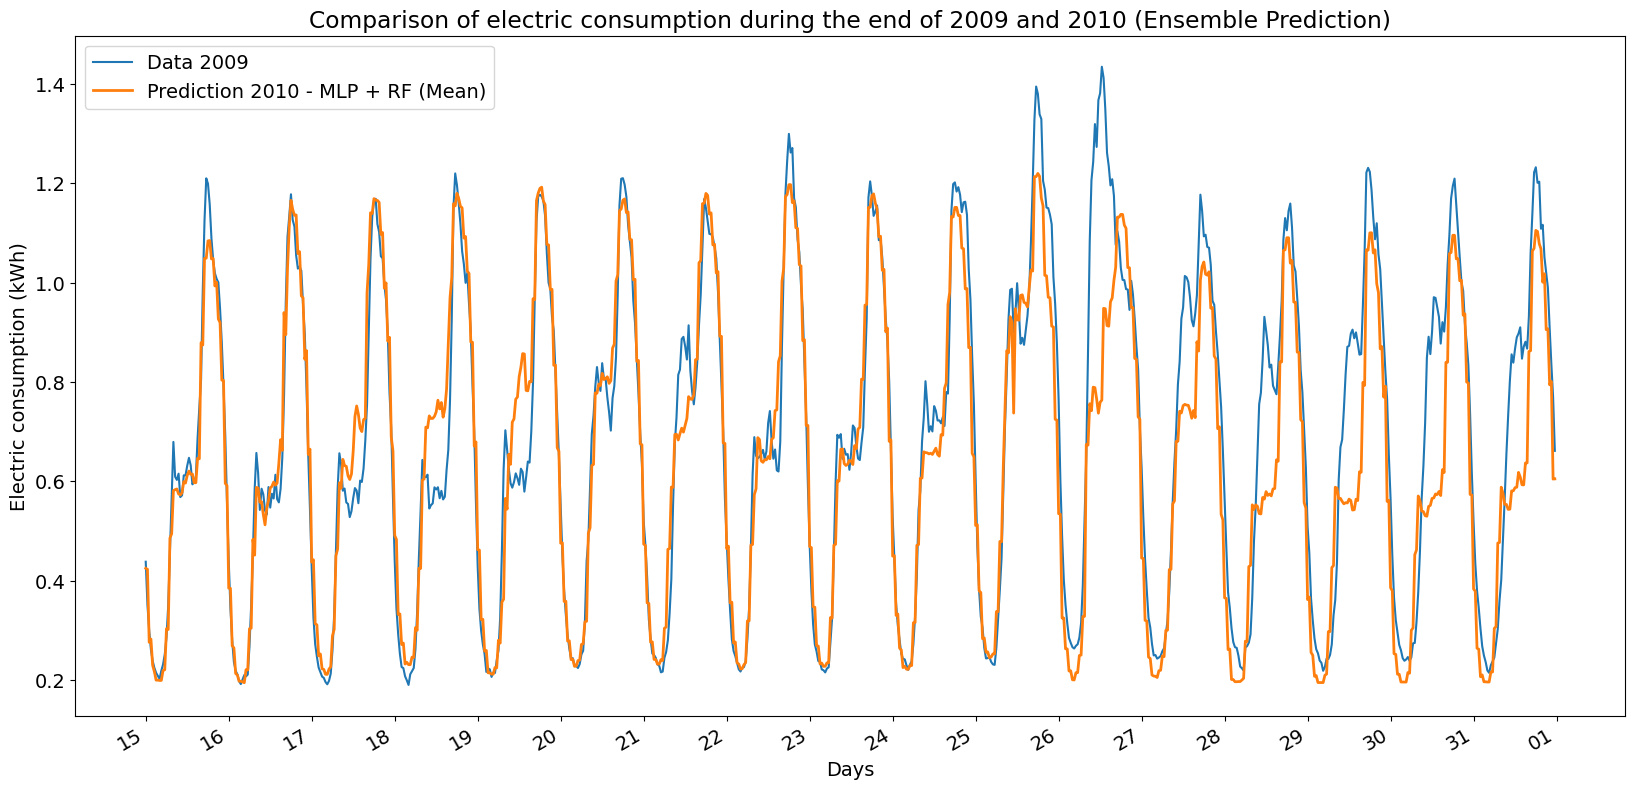

Chemin utilisé : /Users/admin/Projects/energy-consumption-data-analysis-1/data/df_vst_group5.csv
Anciennes valeurs : 24864
Nouvelles valeurs : 816
Total futur : 25680
Longueur dataset : 25680
✅ Fichier mis à jour avec les prédictions ensemble


In [20]:
# ======================================================
# I – ENSEMBLE MODEL : Moyenne MLP + Random Forest
# ======================================================

# Moyenne des prédictions
df_mean = (MLP_prediction + Y_valid_O) / 2


# ======================================================
# II – VISUALISATION (Décembre 2010 vs Décembre 2009)
# ======================================================

date_rng = pd.date_range(
    start='2010-12-15',
    end='2010-12-31 23:59:59',
    freq='30min'
)

fig, ax1 = plt.subplots(figsize=(20,10))
plt.gcf().autofmt_xdate()

plt.title("Comparison of electric consumption during the end of 2009 and 2010 (Ensemble Prediction)")

# Données réelles 2009
ax1.plot(date_rng, Y_dec09, label='Data 2009')

# Prédiction moyenne
ax1.plot(date_rng, df_mean, linewidth=2, label='Prediction 2010 - MLP + RF (Mean)')

ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d'))
ax1.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator())

ax1.legend(loc='upper left')
ax1.set_xlabel('Days')
ax1.set_ylabel('Electric consumption (kWh)')

plt.show()


# ======================================================
# III – AJOUT DES PRÉDICTIONS AU DATASET
# ======================================================

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path().resolve().parent
FILE_PATH = PROJECT_ROOT / "data" / "df_vst_group5.csv"

print("Chemin utilisé :", FILE_PATH)

df = pd.read_csv(FILE_PATH)

# Récupération des anciennes valeurs non nulles
existing_values = df['mean'].dropna().tolist()

# Nouvelles prédictions
new_values = df_mean.tolist()

# Vérification de cohérence
print("Anciennes valeurs :", len(existing_values))
print("Nouvelles valeurs :", len(new_values))
print("Total futur :", len(existing_values) + len(new_values))
print("Longueur dataset :", len(df))

# Fusion
combined_values = existing_values + new_values

# Remplacement colonne
df['mean'] = combined_values

# Sauvegarde
df.to_csv('df_vst_group5.csv', index=False)

print("✅ Fichier mis à jour avec les prédictions ensemble")

### Conclusion – Modèle d’ensemble (MLP + Random Forest)

La combinaison des prédictions du MLP et du Random Forest par moyenne simple permet d’obtenir une prédiction plus stable et plus robuste.

Le modèle d’ensemble reproduit correctement la saisonnalité journalière et l’amplitude des variations observées en décembre 2009. Les pics et creux sont bien alignés temporellement, et les écarts extrêmes sont légèrement atténués, traduisant une réduction de la variance.

Cette approche confirme l’intérêt des techniques d’ensemble : en combinant deux modèles performants mais différents, on améliore la stabilité globale des prédictions tout en conservant un bon niveau de précision.